# __Métodos baseados em árvores:__
<font size=3>

Os **métodos baseados em árvores** são técnicas utilizadas para tarefas de **classificação** e **regressão**, que se destacam pela simplicidade, interpretativa e flexibilidade. Esses métodos funcionam por meio da **divisão recursiva dos dados em subconjuntos**, criando uma **estrutura hierárquica semelhante a uma árvore**, onde cada **nó** interno representa uma **decisão** baseada em um atributo dos dados e cada folha corresponde a uma previsão.

## __1. Árvores de decisão e regressão:__
<font size=3>

Nestes métodos, a ideia central é dividir recursivamente os dados de entrada (os atributos) em regiões, com base em regras de decisão simples (normalmente do tipo "*if* ... *else* ..."), que maximizem algum critério de divisão da árvore ou minimizem o erro.


<font size=3>

Imagine um processo simples, como um banco decidindo se deve aprovar um empréstimo. Um analista poderia seguir um fluxograma:

O cliente tem renda anual > R$ 50.000?
  * **Sim:** O cliente tem um score de crédito > 700?
      * **Sim:** Aprovar Empréstimo.
      * **Não:** Rejeitar Empréstimo.
  * **Não:** O cliente tem algum bem (ex: casa própria)?
      * **Sim:** Aprovar Empréstimo.
      * **Não:** Rejeitar Empréstimo.
    

<font size=3>

Chamamos de **árvores de decisão** o método usado para **classificação**, na qual a árvore divide o espaço de atributos de forma a maximizar a separação entre as classes. Já as **árvores de regressão**
são aquelas usadas para tarefas de **regressão**, onde a árvore tenta particionar os dados de forma a *minimizar o erro quadrático* dentro de cada folha.

As árvores de decisão são caracterizadas por serem **grafos direcionados acíclicos**, onde os **nós** internos representam os critérios de decisão, as **arestas** indicam o caminho seguido com base nos critérios, e as **folhas** correspondem às previsões ou classes finais (para classificação) ou valores preditos (para regressão).

<font size=3><center>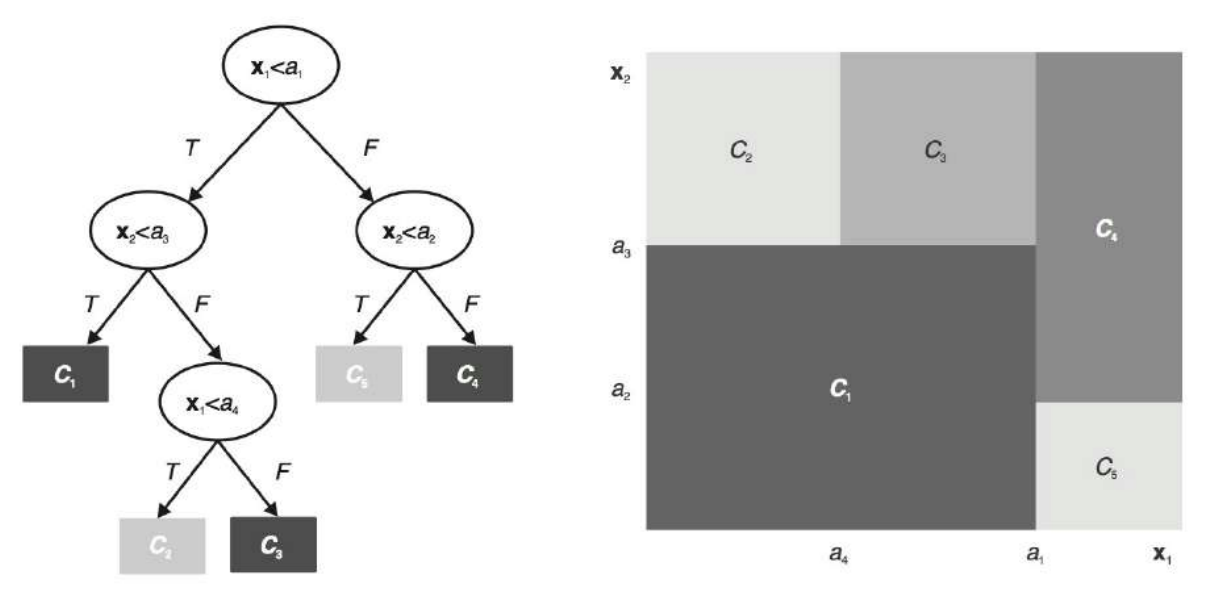</center></pUse><p style="text-align:center;"><em>Figure 6.1 do livro. As variáveis $\mathbf{x}_1$ e $\mathbf{x}_2$ são os atributos dos dados.</em>

### **1.1 Pureza de nós:**
<font size=3>

**Como o algoritmo sabe qual pergunta fazer primeiro?** Por exemplo, por que perguntar sobre a "renda" antes do "score de crédito"?

A árvore busca a pergunta que melhor **divide** e **organiza** os dados, deixando os grupos resultantes o mais **"puros"** possível. Um nó é "puro" se todos os dados nele pertencem à mesma classe. O objetivo do algoritmo é criar "folhas" (os nós finais da árvore) que sejam 100% puras.

Para medir isso, usamos um conceito de **Impureza**. O algoritmo irá escolher a pergunta (a divisão) que mais *reduz a impureza* total. Existem duas métricas principais para medir a impureza em um nó de classificação:

1. **Índice Gini (_Gini Impurity_):** O Índice Gini mede a probabilidade de um elemento aleatório do nó ser classificado incorretamente, se fosse rotulado aleatoriamente de acordo com a distribuição das classes no nó (é a métrica padrão no Scikit-learn).
    
A fórmula para um nó $n$ é dado por  
$$
G(n) = 1 - \sum_{k=1}^{K} (p_{k})^2 ,
$$
onde:
* $K$ é o número de classes.
* $p_k$ é a proporção de amostras da classe $k$ no nó $n$.
<br>

**Interpretação:**    
* **$G(n) = 0$ (pureza perfeita):** O nó é 100% puro. Ex: $[100 A,\, 0 B] \rightarrow 1 - (1^2 + 0^2) = 0$.

* **$G(n) = 0.5$ (impureza máxima para 2 classes):** O nó está perfeitamente dividido. Ex: $[50 A,\, 50 B]\rightarrow 1 - (0.5^2 + 0.5^2) = 0.5$.
<br>

2. **Entropia:** Vinda da teoria da informação, a entropia mede o nível de "desordem" em um nó.
    
A fórmula é:

$$
H(n) = - \sum_{k=1}^{K} p_k \log_2(p_k) .
$$
<br>

**Interpretação:**
* **$H(n) = 0$ (pureza perfeita):** O nó é 100% puro. A "desordem" é zero, pois sabemos exatamente qual é a classe.
* **$H(n) = 1$ (impureza máxima para 2 classes):** O nó está perfeitamente dividido (50/50). A "desordem" é máxima.


### **1.2 Critério de divisão:**
<font size=3>

O algoritmo não otimiza a impureza diretamente, mas sim o **Ganho de Informação** (*information gain* — IG). Essa métrica trata-se da diferença entre a impureza (índice de Gini) do nó "pai" (antes da divisão) e a média ponderada da impureza dos dois nós "filhos" (depois da divisão).

$$
\text{IG}(\text{Pai}, \text{Divisão}) = G(\text{Pai}) - \left[\frac{N_{\text{filho-1}}}{N_{\text{Pai}}} G(\text{filho-1}) + \frac{N_{\text{filho-2}}}{N_{\text{Pai}}} G(\text{filho-2}) \right]
$$

>O algoritmo é **_greedy_ (ganancioso)**: em cada nó, ele irá testar *todos os atributos* e *todos os limiares (valores de corte do atributo) possíveis* para encontrar a divisão (atributo + limiar) que **maximiza o Ganho de Informação**.

<br>

**E quanto à regressão?** Para regressão, o objetivo não é "pureza" de classe, mas sim encontrar divisões que deixem os valores $y$ nos nós filhos o mais próximos possível uns dos outros.

A métrica de "impureza" mais comum aqui é o **erro quadrático médio (MSE)**,
$$
    MSE(n) = \frac{1}{N_n} \sum_{i \in n} (y_i - \bar{y}_n)^2 \, ,
$$
onde $\bar{y}_n$ é simplesmente a **média** de todos os valores $y$ no nó $n$. A árvore tenta encontrar divisões que minimizem o MSE nos nós filhos.

### **1.3 O algoritmo de decisão:**
<font size=3>
    
Vamos consolidar como o algoritmo funciona:
1. **Comece no topo (nó raiz):** O algoritmo começa com *todo* o conjunto de dados de treinamento em um único nó;

2. **Encontre a melhor divisão:**
* O algoritmo itera sobre todos os atributos $x^j$ (ex: "renda", "score de crédito").
* Para cada atributo $x^j$, ele itera sobre todos os limiares possíveis (ex: "renda > 30k", "renda \> 40k", "renda > 50k"...).
* Para cada par (atributo, limiar), ele calcula o **ganho de informação** que essa divisão traria.
* A divisão que **maximiza o IG** é escolhida.
<br>

3. **Divida os dados:** O nó é dividido em dois nós filhos (ex: "renda > 50k" e "renda <= 50k");

4. **Repita (recursão):** O algoritmo repete os passos 2 e 3 para *cada nó filho*;

5. **Pare de crescer (critérios de parada):** A recursão para quando uma condição é atingida:
* O nó se torna **perfeitamente puro** ($G(n)=0$ ou $H(n)=0$).
* A **profundidade máxima** da árvore é atingida (hiperparâmetro `max_depth`).
* O número de amostras no nó é muito pequeno para dividir (hiperparâmetro `min_samples_split`).
* O número de amostras em um nó folha seria muito pequeno (hiperparâmetro `min_samples_leaf`).

Esses critérios de parada (especialmente `max_depth`) são a nossa primeira ferramenta contra o maior inimigo da árvore de decisão: o **overfitting**.


<font size=3><center>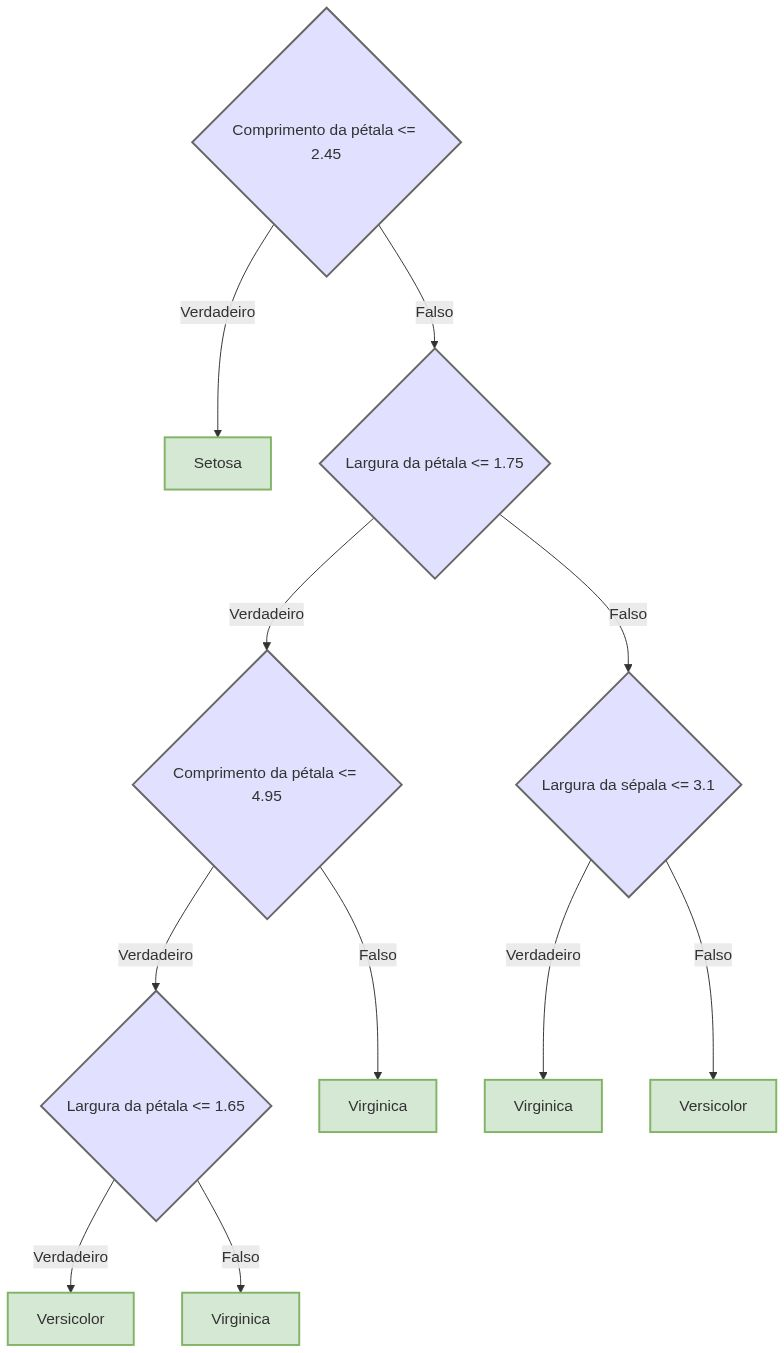</center>

### **1.4 Exemplo de classificação:**
<font size=3>

Vamos utilizar o [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) para resolver o problema das *flores de íris*.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# importando os dados:
dset = load_iris()

X = dset.data
y = dset.target

# dividindo entre dados de treino e teste:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# definindo o modelo de classificação:
model = DecisionTreeClassifier(criterion='entropy')

# fitando os dados de treino:
model.fit(X_train, y_train)

# fazendo predições com dados de teste:
y_pred = model.predict(X_test)

# avaliando o modelo com a métrica da acurácia:
print(f"Acurácia = {accuracy_score(y_test, y_pred):.3f}")

<font size=3>
<br>

Para visualizar a árvore, podemos utilizar as funções [`plot_tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) e [`export_text`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import export_text

In [ ]:
# vamos plotar a árvore de decisão:
plt.figure(figsize=(16, 7))
plot_tree(model, filled=True, feature_names=dset.feature_names, class_names=dset.target_names)
plt.show()

In [ ]:
print(export_text(model, feature_names=dset.feature_names))

<font size=3>

O objeto `model` apresenta um atributo chamado `feature_importances`, que se baseia na função de custo, mostando o nível de importância que a variável $x^j$ teve na decisão da classificação.

In [ ]:
print("Importância dos atributos:", model.feature_importances_)

In [ ]:
# para visualizar as importâncias, vamos definir uma Series do pandas - uma lista com etiquetas:
importances = pd.Series(model.feature_importances_, index=dset.feature_names)

importances.sort_values(ascending=True).plot(kind='barh', title='Importância dos atributos', figsize=(8, 4))
plt.xlabel("Importância")
plt.show()

### **1.5 Exemplo de regressão:**
<font size=3>

Para esse exemplo, iremos utilizar o [`DecisionTreeRegression`](https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html) para resolver o problema de *preços de casas*.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

In [ ]:
dset = fetch_california_housing()

X = dset.data
y = dset.target

# dividindo os dados em treinamento e teste:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# definindo modelo de regressão:
model = DecisionTreeRegressor(random_state=7) # considerando embaralhamento das amostras a cada ramificação

# fitando os dados de treinamento:
model.fit(X_train, y_train)

# previsões no conjunto de teste:
y_pred = model.predict(X_test)

# avaliando o modelo:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático médio (MSE): {mse:.4f}")
print(f"Coeficiente de determinação (R²): {r2:.4f}")

### **1.6 Estratégias de poda:**
<font size=3>

As **estratégias de poda** em árvores de decisão são técnicas usadas para **reduzir a complexidade** da árvore e evitar **overfitting**. A poda é geralmente feita de duas maneiras:

1. **Pré-poda (*pre-pruning*):** Interrompe o crescimento da árvore **antes** que ela fique muito complexa, com base nos critérios como:  
    - Limitar a **profundidade máxima** da árvore.  
    - Definir um **número mínimo de amostras** em um nó para permitir a divisão.  
    - Estabelecer um **limite de ganho de informação** (se a divisão não melhorar significativamente, para).  
    <br>

2. **Pós-poda (*post-pruning*):** Primeiro constrói a árvore completa e **depois remove** ramos desnecessários, que não melhoram a previsão do conjunto de teste.


In [ ]:
# definindo o modelo com estratégias de pré-poda:
model = DecisionTreeRegressor(max_depth=3,           # limita a profundidade máxima da árvore (limite de 3 níveis para melhor visualização da árvore abaixo)
                              min_samples_split=20,  # número mínimo de amostras para dividir um nó
                              min_samples_leaf=10,   # número mínimo de amostras em cada folha
                              random_state=42)

model.fit(X_train, y_train)

# previsões no conjunto de teste:
y_pred = model.predict(X_test)

# avaliando o modelo:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático médio (MSE): {mse:.4f}")
print(f"Coeficiente de determinação (R²): {r2:.4f}")

In [ ]:
# vamos plotar a árvore de decisão:
plt.figure(figsize=(16, 7))
plot_tree(model, filled=True, feature_names=dset.feature_names, class_names=dset.target_names)
plt.show()

### **1.7 Vantagens e desvantagens:**
<font size=3>
    
- **Vantagens:**
    - Simples de entender e interpretar (pode ser visualizado como um fluxograma);
    - Lida bem com dados categóricos e contínuos;
    - Não exige normalização dos dados.
    <br>

- **Desvantagens:**
    - Tendência a *overfitting* (árvores muito profundas);
    - Pequenas variações nos dados podem causar grandes mudanças na árvore.
      

## __2. Modelo *Random Forest*:__
<font size=3>

O modelo de **árvores de decisão** é poderoso e interpretável, mas sofre do problema de **alta variância**, o que o torna instável e tendencioso a se ajustar excessivamente aos dados de treinamento. Como solução, em vez de treinar uma única árvore, iremos treinar uma "floresta" (centenas de árvores) e, para tomar uma decisão final, faremos uma **votação**. Este é o modelo **_Random Forest_**.

<font size=3><center>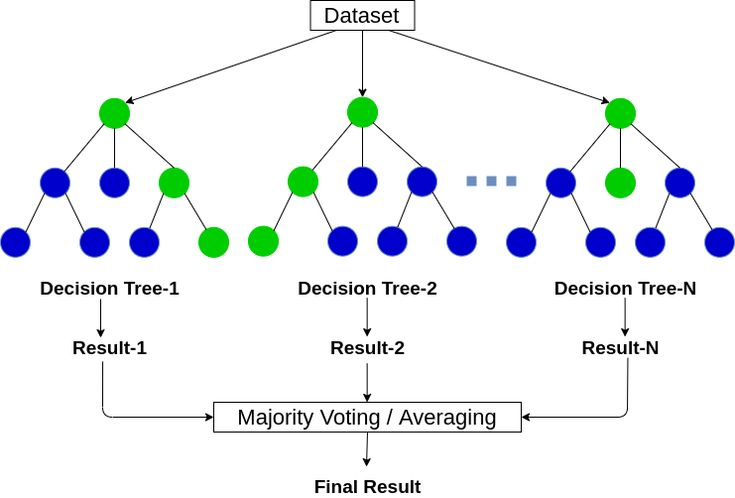</center>

### **2.1 Método de _ensemble_:**
<font size=3>
    
O *random forest* é um método de *ensemble* que combina **duas técnicas** poderosas para criar um modelo robusto que reduz drasticamente o *overfitting*:

1. **_Boostrap_:** Para garantir que cada árvore seja diferente, não treinamos todas elas com o mesmo conjunto de dados. Em vez disso, para cada árvore, damos a ela uma "visão" ligeiramente diferente dos dados. Fazemos isso através de **amostragem com reposição** (*bootstrap*).

2. **Aleatoriedade de atributos:** No caso em que um atributo for muito dominante, a maioria das árvores ainda a escolheria como a primeira divisão, tornando-as muito correlacionadas. Para forçar as árvores a serem *ainda mais diferentes*, o *random forest* introduz uma segunda camada de aleatoriedade: em *cada nó* de *cada árvore*, ao decidir a melhor divisão, o algoritmo não considera todas as atributos. Ele sorteia um **subconjunto aleatório de atributos**.

>O resultado é uma "floresta" de árvores *decorrelacionadas*. Cada uma é uma especialista fraca por si só, mas juntas, através da votação, elas formam um dos modelos mais robustos e eficazes do machine learning.

**Durante a previsão**, o algoritmo utiliza a **moda** das respostas de cada árvore para classificação, ou a **média** para tarefas de regressão.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# definindo o modelo:
model = RandomForestRegressor(n_estimators=100,
                              max_features='sqrt',
                              oob_score=True,
                              random_state=42,
                              n_jobs=-1 # usa todos os processadores disponíveis em paralelo
                             )

# treinando o modelo:
model.fit(X_train, y_train)

# predição e avaliação:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático médio (MSE): {mse:.2f}")
print(f"Coeficiente de determinação (R²): {r2:.2f}")
print(f"R² com dados OOB: {model.oob_score_:.2f}")

<font size=3>
<br>
    
Devido à amostragem com reposição, cada árvore é treinada em média em apenas $\sim 65\%$ das amostras de treinamento. Os $\sim 35\%$ restantes, que não foram vistos por aquela árvore específica, são as amostras **"_Out-of-Bag_" (OOB)**.

Para cada amostra $x_i$ no treino, podemos fazer uma previsão usando *apenas* as árvores que *não* viram $x_i$ durante seu treinamento. Ao fazer isso para todas as amostras, obtemos uma estimativa de acurácia/$R^2$ (o `oob_score_`) sem precisar de um conjunto de teste separado.

> **Observação:** Você notará que a acurácia do *Random Forest* é geralmente igual ou (em datasets mais complexos) significativamente melhor que a da árvore única. Mais importante, o modelo é muito mais estável. A métrica de OOB nos dá uma estimativa muito confiável de como o modelo se sairá em dados novos.

In [ ]:
# para visualizar as importâncias, vamos definir uma Series do pandas - uma lista com etiquetas:
importances = pd.Series(model.feature_importances_, index=dset.feature_names)

importances.sort_values(ascending=True).plot(kind='barh', title='Importância dos atributos', figsize=(8, 4))
plt.xlabel("Importância")
plt.show()

<font size=3>
    
>**Observação:** Ao contrário da visualização de uma árvore, que é instável, este gráfico é robusto. Ele nos diz quais features o modelo em geral considera mais preditivas.

### **2.2 Vantagens e desvantagens:**
<font size=3>
    
- **Vantagens:**
    - **Alta acurácia**, especialmente em comparação com uma única árvore.
    - **Robustez a _overfitting_**, graças à aleatoriedade e ao agrupamento de várias árvores.
    - **Capacidade de lidar com dados de alta dimensionalidade e correlação entre variáveis.**
    - Funciona bem com **valores ausentes** e **variáveis categóricas**.

- **Desvantagens:**
    - Pode ser **mais lento** para prever, especialmente com muitas árvores.
    - Menos interpretável do que uma única árvore de decisão.
      

## **3. Modelo _Gradient boosting_:**
<font size=3>

Agora, vamos explorar uma outra abordagem de *ensemble*, chamada **_boosting_**. Em vez de uma "democracia" paralela, o *boosting* funciona como uma **"linha de montagem" sequencial**.

### **3.1 O conceito de _boosting_:**
<font size=3>

Imagine que você está treinando uma equipe de especialistas para realizar uma tarefa:
  * O primeiro "especialista" (uma árvore) faz uma primeira tentativa. Ele acerta algumas coisas e erra outras.
  * O segundo especialista foca *apenas* no que o primeiro errou. Ele é treinado para **corrigir os erros (resíduos)** do primeiro.
  * O terceiro especialista foca nos erros que *ainda restam* após a correção do segundo.
  * ...e assim por diante.

Cada novo modelo "reforça" (*boosts*) o desempenho do time, focando especificamente nas deficiências existentes. O *Gradient Boosting* é uma implementação específica dessa ideia, onde "focar nos erros" é generalizado para um conceito matemático: **otimizar uma função de perda descendo o seu gradiente**.

> Ao contrário do *Random Forest*, que usa árvores profundas para reduzir a variância, o *Gradient Boosting* usa árvores muito **rasas** (chamadas de *"weak learners"*, ou aprendizes fracos, muitas vezes com `max_depth` de 3 a 8). Ele começa com um modelo de alto viés (muito simples) e, sequencialmente, reduz esse viés a cada etapa.


### **3.2 Otimização por gradiente:**
<font size=3>

O algoritmo define $M$ árvores para trabalharem de forma sequencial,
$$
    F_m(x) = F_{m-1}(x) + \nu\,h_m(x) \, ,
$$
onde a previsão no passo $m$ é a previsão do passo $m-1$ mais uma nova árvore $h_m(x)$, tal que $m=1,\dots, M$. O hiperparâmetro $\nu$ é a **taxa de aprendizagem** (*learning rate*), usada para tornar o processo mais lento, a fim de evitar *overfitting*. Para $m=1$, temos a primeira árvore $F_1 = F_0 + h_1$, na qual $F_0$ é a média ou moda dos dados de treinamento.

> **O objetivo** é encontrar a melhor árvore nova $h_m(x)$ que, quando adicionada ao modelo, mais reduz a **função de perda** (métrica que avalia a predição com dados de teste). A matemática nos diz que a direção de "redução mais rápida" da perda é o **gradiente negativo** da função de perda.

> O gradiente é um operador que **aponta** a direção e magnitude da taxa de variação de uma função.

<font size=3>

Para ilustrar essa ideia, vamos considerar a função de perda MSE,
$$
    L(y,\, F(x)) = \frac12\left(y - F(x)\right)^2 \, .
$$
Aqui, definimos MSE com o fator $1/2$ para simplificar o resultado de sua derivada. Perguntar qual $h_m$ reduz $L$, é o mesmo que perguntar "como a função de perda varia em relação à $F_{m-1}\,$?" ou ainda, "qual a derivada de $L$ em relação à $F_{m-1}\,$?". Aqui, é importante perceber que $F_{m-1}$ é o modelo que temos definido agora, e $F_m$ é o modelo a ser construído.

$$
    \frac{\partial L(y,\, F_{m-1})}{\partial F_{m-1}} = \frac{\partial}{\partial F_{m-1}} \left[ \frac{1}{2} (y - F_{m-1})^2 \right] = -(y - F_{m-1}) \, .
$$
Assim, o negativo do gradiente é o que chamaremos de **resíduo**, $r_m \equiv y - F_{m-1}(x)$. Esta é a peça-chave para o processo recursivo do treinamento do modelo final.


### **3.3 O algoritmo:**
<font size=3>

1.  **Inicialize o Modelo ($F_0$):** Faça uma primeira previsão "ingênua". Para regressão, $F_0(x)$ é simplesmente a **média** ou **moda** de todos os $y$ do conjunto de treino.

2.  **Itere de $m = 1$ até $M$ (`n_estimators`):**
    - **Calcule os resíduos ($r_m$):** Calcule o gradiente negativo da função de perda. No caso simples de regressão MSE, $r_m = y - F_{m-1}(x)$.


    - **Treine um aprendiz fraco ($h_m$):** Treine uma nova árvore onde os atributos são $x$ e o alvo são os resíduos $r_m$ calculados no passo anterior.


    - **Atualize o Modelo ($F_m$):** Adicione a previsão desta nova árvore ao modelo geral, ponderada pela taxa de aprendizado: $F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$

4.  **Resultado Final:** O modelo final $F_M(x)$ é a soma do palpite inicial $F_0$ e todas as $M$ árvores de correção: $F_M(x) = F_0 + \nu\, h_1(x) + \nu\, h_2(x) + \cdots + \nu \, h_M(x)$.


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
# definindo o modelo:
model = GradientBoostingRegressor(n_estimators=100,    # 100 árvores na sequência
                                  learning_rate=0.1,  # taxa de aprendizado
                                  max_depth=3,        # árvores "rasas"
                                  random_state=42)

# treinando o modelo:
model.fit(X_train, y_train)

# predição e avaliação:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático médio (MSE): {mse:.2f}")
print(f"Coeficiente de determinação (R²): {r2:.2f}")

In [ ]:
# para visualizar as importâncias, vamos definir uma Series do pandas - uma lista com etiquetas:
importances = pd.Series(model.feature_importances_, index=dset.feature_names)

importances.sort_values(ascending=True).plot(kind='barh', title='Importância dos atributos', figsize=(8, 4))
plt.xlabel("Importância")
plt.show()

<font size=3>

> O *Gradient Boosting* é a base para os algoritmos mais famosos como **XGBoost**, **LightGBM** e **CatBoost**, que são implementações altamente otimizadas deste mesmo conceito.


### **3.4 Vantagens e desvantagens:**
<font size=3>
    
- **Vantagens:**
    * **Alta Acurácia:** Frequentemente supera o Random Forest.
    * **Flexibilidade:** Pode otimizar qualquer função de perda diferenciável (MSE, MAE, Log-Loss, etc.).
    <br>

- **Desvantagens:**
    * **Mais Sensível a Hiperparâmetros:** O `learning_rate` e o `n_estimators` têm uma relação delicada. Um `learning_rate` muito alto pode causar overfitting.
    * **Treinamento Lento:** O processo é **sequencial**, não pode ser facilmente paralelizado (cada árvore depende da anterior). O Random Forest treina muito mais rápido.


## __Referências:__
<font size=3>

- **(6.1)**: K. Faceli, _Inteligência artificial: uma abordagem de aprendizado de máquina_. Grupo Gen - LTC, 2011.
  